In [1]:
%load_ext kedro.ipython

The kedro.ipython extension is already loaded. To reload it, use:
  %reload_ext kedro.ipython


In [2]:
!uv pip install --upgrade seaborn matplotlib

Using Python 3.12.7 environment at: C:\Users\arczi\source\repos\Mini\Msi\wsi-reg-cls\wsi-reg\.venv
Resolved 14 packages in 165ms
Prepared 5 packages in 2ms
Uninstalled 5 packages in 918ms
Installed 5 packages in 1.06s
 - fonttools==4.61.1
 + fonttools==4.62.1
 - kiwisolver==1.4.9
 + kiwisolver==1.5.0
 - numpy==2.4.2
 + numpy==2.4.3
 - pandas==2.3.3
 + pandas==3.0.1
 - seaborn==0.12.2
 + seaborn==0.13.2


In [3]:
import pandas as pd
pd.set_option('display.max_columns', None)
df = catalog.load("domy_fill_missing_values")
df = df.sort_index(axis=1)

[03/25/26 20:05:24] INFO     Loading data from domy_fill_missing_values (CSVDataset)...        ]8;id=698799;file://C:\Users\arczi\source\repos\Mini\Msi\wsi-reg-cls\wsi-reg\.venv\Lib\site-packages\kedro\io\data_catalog.py\data_catalog.py]8;;\:]8;id=424231;file://C:\Users\arczi\source\repos\Mini\Msi\wsi-reg-cls\wsi-reg\.venv\Lib\site-packages\kedro\io\data_catalog.py#1048\1048]8;;\

In [4]:
    threshold = 0.92
    cols_to_drop = []
    for col in df.columns:
        max_freq = df[col].value_counts(normalize=True, dropna=False).max()
        if max_freq >= threshold and df[col].dtype in ['object', 'string']:
            cols_to_drop.append(col)

    print(cols_to_drop)
    for col in cols_to_drop:
        df.drop(col, axis=1, inplace=True)

['Alley', 'CentralAir', 'Condition2', 'Functional', 'Heating', 'LandSlope', 'MiscFeature', 'PoolQC', 'RoofMatl', 'Street', 'Utilities']


In [5]:
grades = {'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa': 2, 'Po': 1, 'Lack': 0}
columns_to_map = ['ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond', 'HeatingQC', 'KitchenQual', 'FireplaceQu', 'GarageQual', 'GarageCond']

for col in columns_to_map:
    if col in df.columns:
        df[col] = df[col].map(grades)

if 'BsmtExposure' in df.columns:
    grades = {'Lack': 0, 'No': 1, 'Mn': 2, 'Av': 3, 'Gd': 4}
    df['BsmtExposure'] = df['BsmtExposure'].map(grades)

if 'BsmtFinType1' in df.columns:
    grades = {'Lack': 0, 'Unf': 1, 'LwQ': 2, 'Rec': 3, 'BLQ': 4, 'ALQ': 5, 'GLQ': 6}
    df['BsmtFinType1'] = df['BsmtFinType1'].map(grades)
    df.rename(columns={'BsmtFinType1': 'BsmtFinType1Ovrl'}, inplace=True)

if 'CentralAir' in df.columns:
    df['CentralAir'] = df['CentralAir'].map({'Y': 1, 'N': 0})

if 'Condition1' in df.columns:
    grades = {'Artery': 'Noise', 'RRAn': 'Noise', 'RRAe': 'Noise', 'Feedr': 'Noise', 'RRNn': 'Noise', 'RRNe': 'Noise', 'Norm': 'Norm', 'PosN': 'Pos', 'PosA': 'Pos'}
    df['Condition1'] = df['Condition1'].map(grades)

if 'Electrical' in df.columns:
    df['Electrical'] = df['Electrical'].apply(lambda x: 1 if x == 'SBrkr' else 0)
    df.rename(columns={'Electrical': 'IsStandardElectrical'}, inplace=True)

if 'Fence' in df.columns:
    grades = {'NoFence': 0, 'MnPrv': 1, 'MnWw': 1, 'GdWo': 2, 'GdPrv': 2}
    df['Fence'] = df['Fence'].map(grades)
    df.rename(columns={'Fence': 'FenceOvrl'}, inplace=True)

if 'GarageFinish' in df.columns:
    grades = {'Lack': 0, 'Unf': 1, 'RFn': 2, 'Fin': 3}
    df['GarageFinish'] = df['GarageFinish'].map(grades)

if 'LandContour' in df.columns:
    df['LandContour'] = df['LandContour'].apply(lambda x: 1 if x == 'Lvl' else 0)
    df.rename(columns={'LandContour': 'IsFlat'}, inplace=True)

if 'LotShape' in df.columns:
    grades = {'IR3': 1, 'IR2': 2, 'IR1': 3, 'Reg': 4}
    df['LotShape'] = df['LotShape'].map(grades)

if 'PavedDrive' in df.columns:
    df['PavedDrive'] = df['PavedDrive'].map({'Y': 1, 'N': 0, 'P': 1})

if 'MasVnrType' in df.columns:
    df['MasVnrType'] = df['MasVnrType'].replace(['BrkFace', 'BrkCmn'], 'Brick')

In [6]:
    threshold = 0.1

    not_numeric_columns = df.select_dtypes(include=['object', 'string']).columns.tolist()
    columns_to_check = [col for col in not_numeric_columns if
                         col not in ['Exterior1st', 'Exterior2nd', 'Neighborhood']]

    for col in columns_to_check:
        freq = df[col].value_counts(normalize=True)
        rare_categories = freq[freq < threshold].index.tolist()

        if rare_categories:
            df[col] = df[col].replace(rare_categories, 'Other')

['BldgType', 'BsmtFinType2', 'Condition1', 'Foundation', 'GarageType', 'HouseStyle', 'LotConfig', 'MSZoning', 'MasVnrType', 'RoofStyle', 'SaleCondition', 'SaleType']


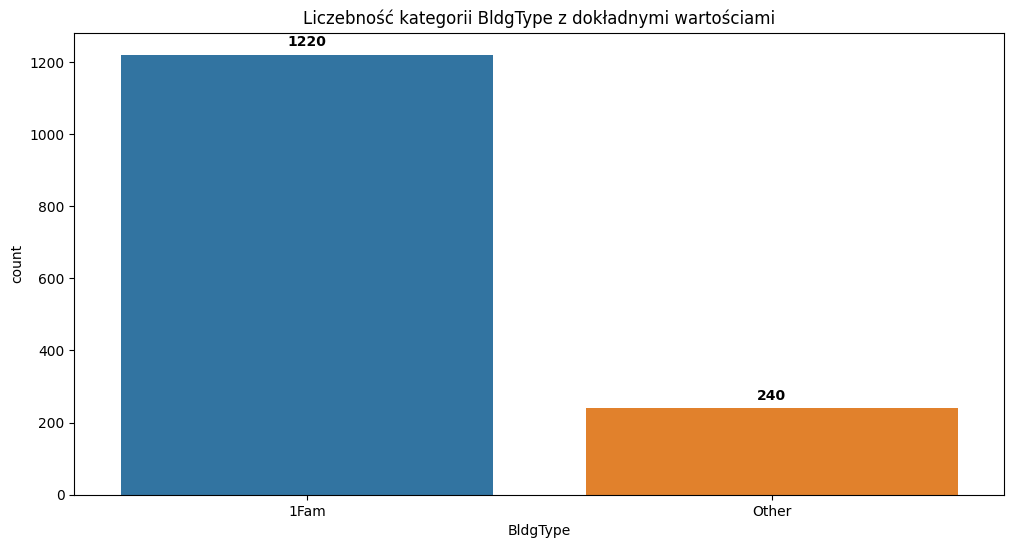

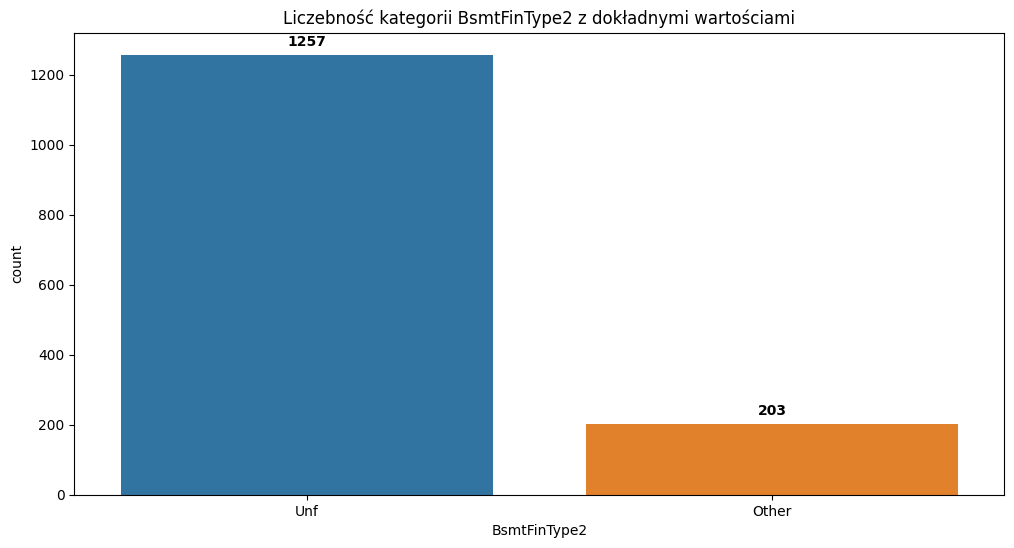

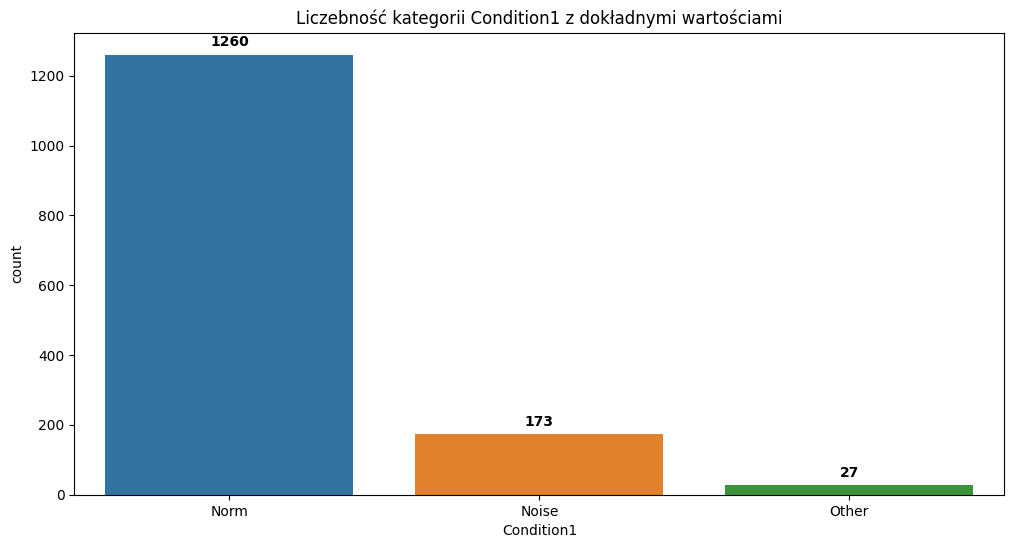

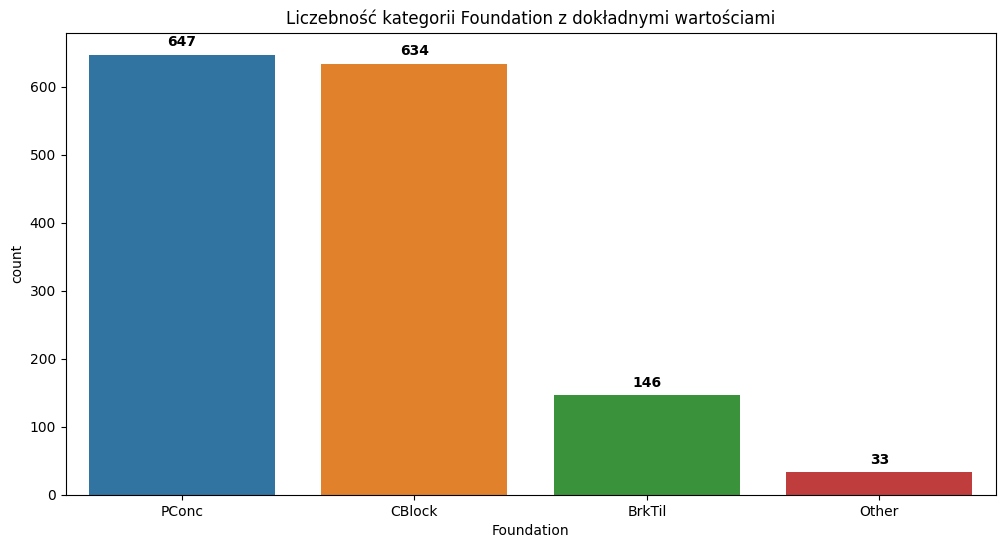

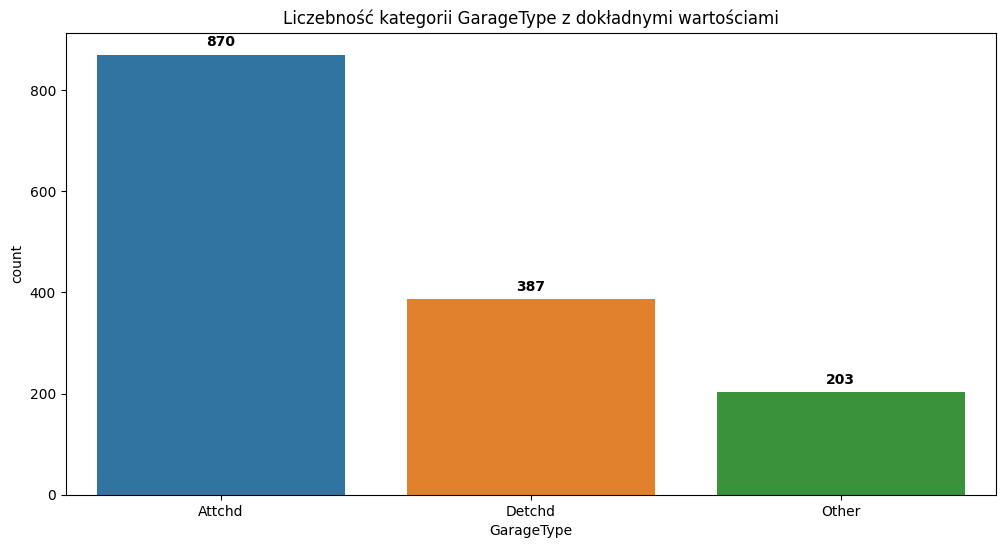

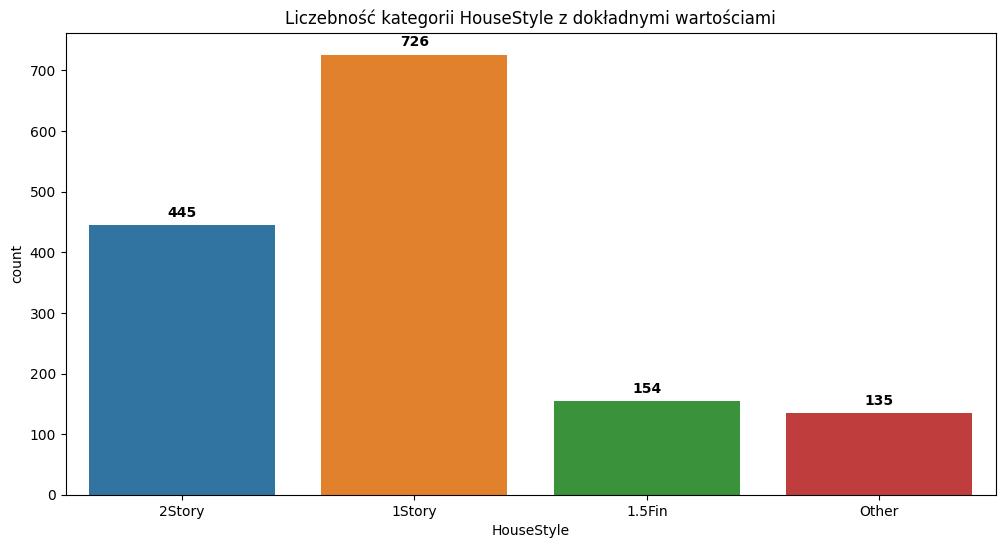

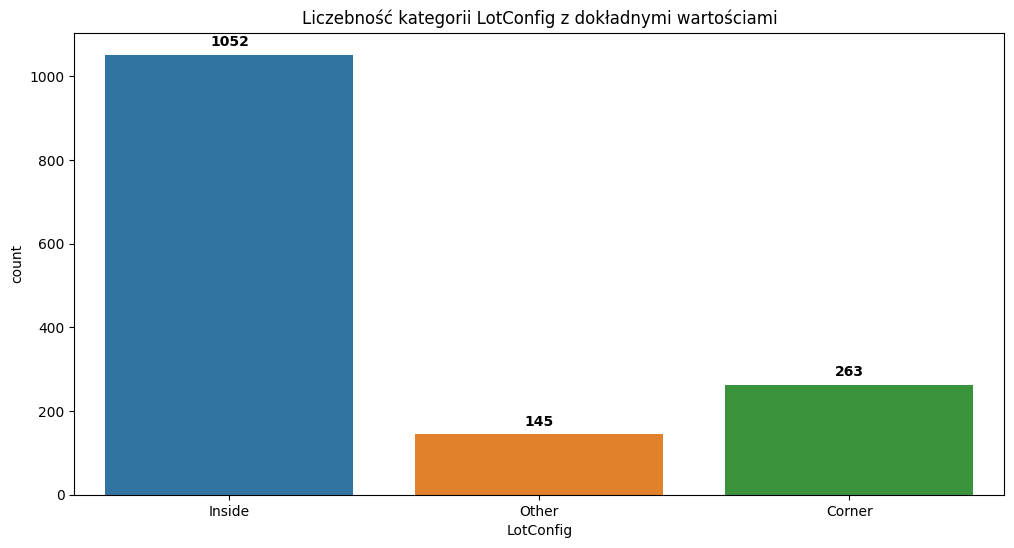

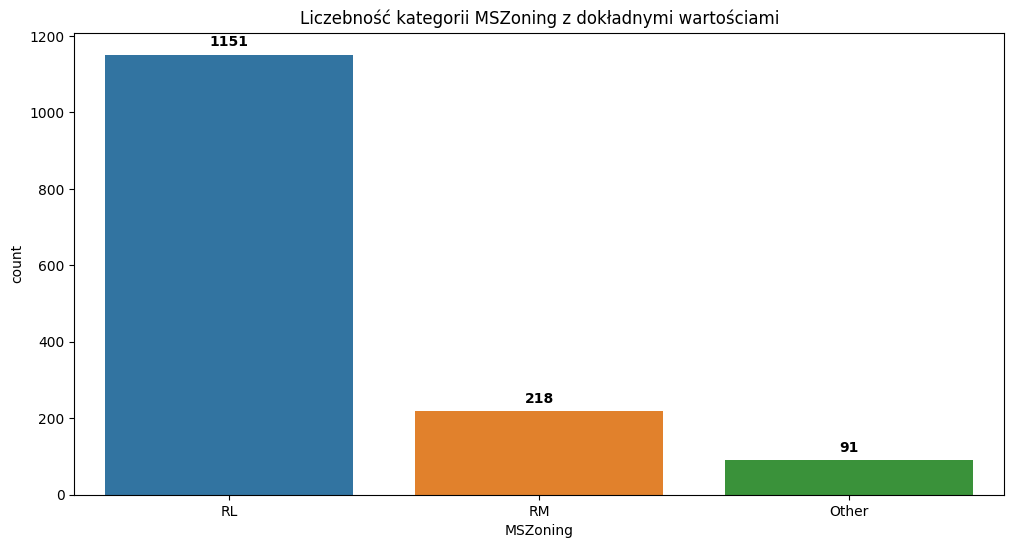

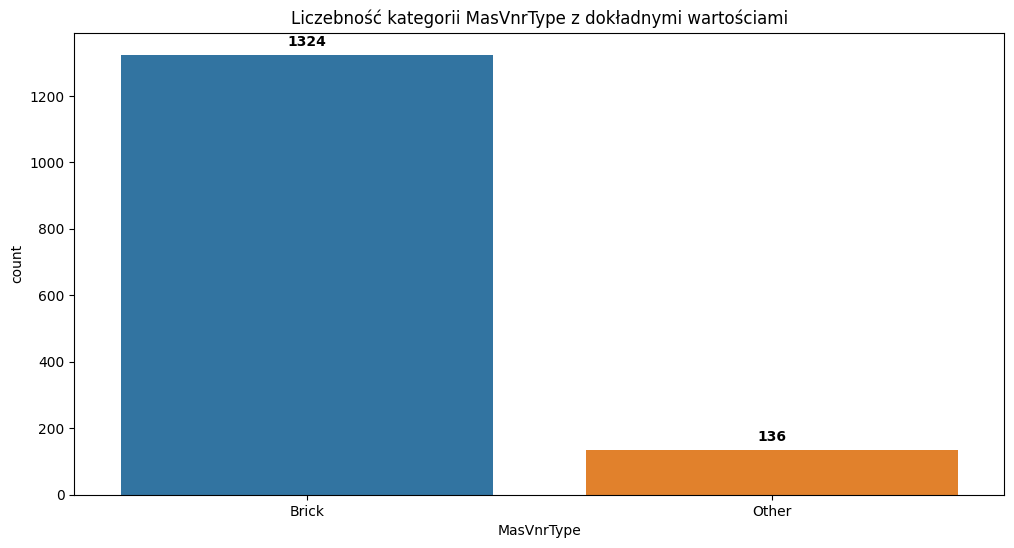

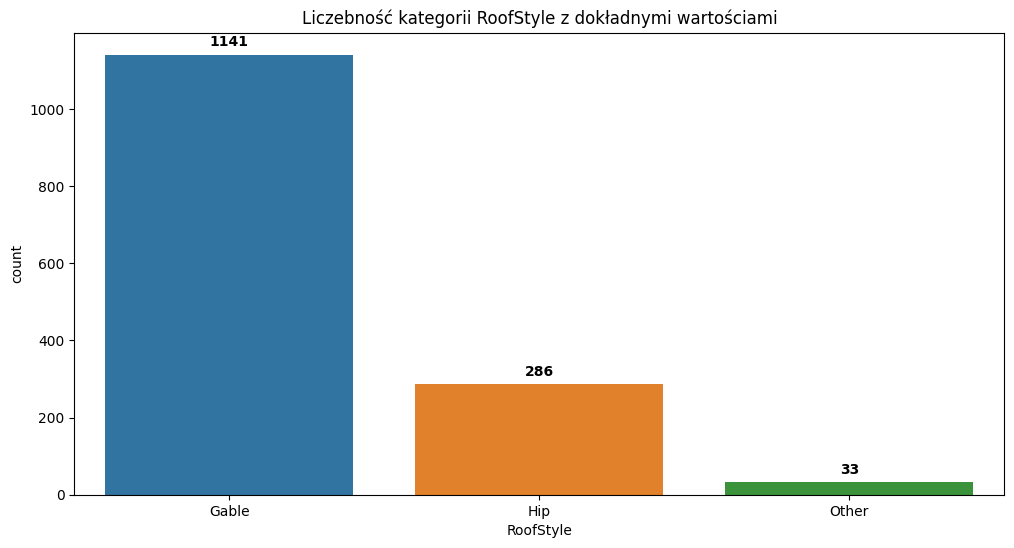

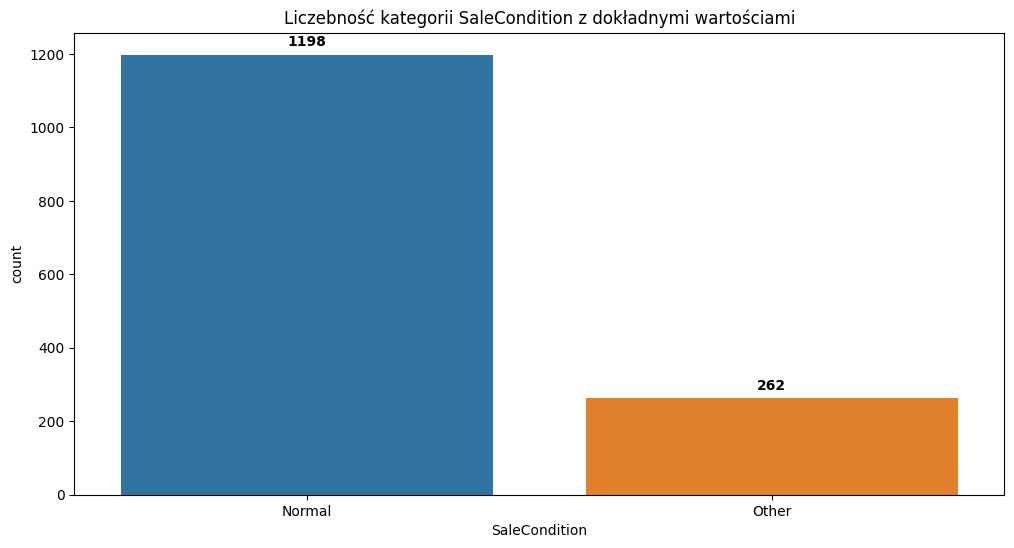

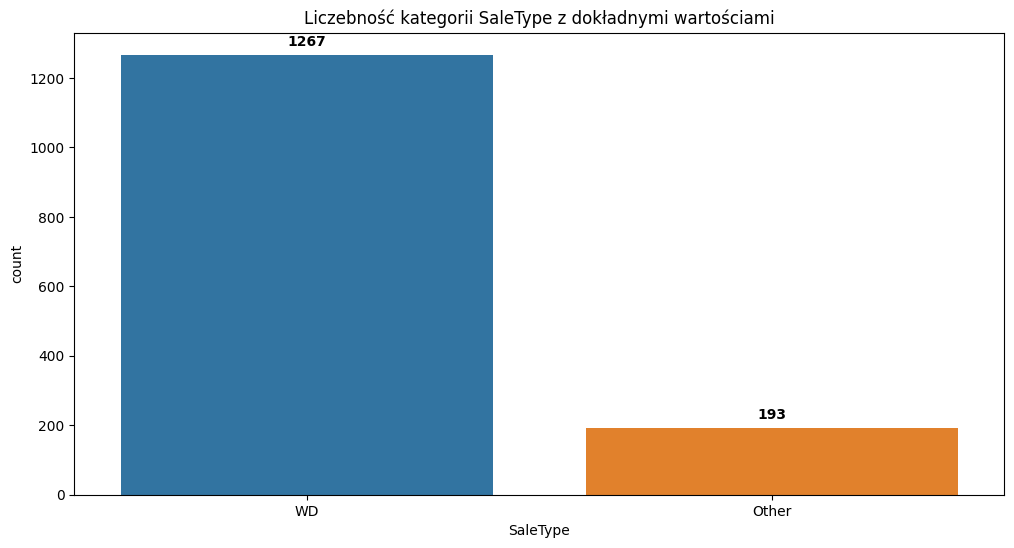

In [7]:
df = df.sort_index(axis=1)
not_numeric_columns = df.select_dtypes(include=['object', 'string']).columns.tolist()
columns_to_draw = [col for col in not_numeric_columns if
                         col not in ['Exterior1st', 'Exterior2nd', 'Neighborhood']]
print(columns_to_draw)
import seaborn as sns
import matplotlib.pyplot as plt
df_cat_s = df.sort_index(axis=1)
for col in columns_to_draw:
    plt.figure(figsize=(12, 6))
    ax = sns.countplot(data=df, x=col)
    
    # Dodawanie liczb nad słupkami
    for p in ax.patches:
        ax.annotate(format(p.get_height(), '.0f'), 
                       (p.get_x() + p.get_width() / 2., p.get_height()), 
                       ha = 'center', va = 'center', 
                       xytext = (0, 9), 
                       textcoords = 'offset points',
                       fontsize=10,
                       fontweight='bold')
    
    plt.title("Liczebność kategorii " + col + " z dokładnymi wartościami")
    plt.savefig("tabela_z_matplotlib.png", bbox_inches='tight', dpi=300)
    plt.show()

In [8]:
df

,1stFlrSF,2ndFlrSF,3SsnPorch,BedroomAbvGr,BldgType,BsmtCond,BsmtExposure,BsmtFinSF1,BsmtFinSF2,BsmtFinType1Ovrl,BsmtFinType2,BsmtFullBath,BsmtHalfBath,BsmtQual,BsmtUnfSF,Condition1,EnclosedPorch,ExterCond,ExterQual,Exterior1st,Exterior2nd,FenceOvrl,FireplaceQu,Fireplaces,Foundation,FullBath,GarageArea,GarageCars,GarageCond,GarageFinish,GarageQual,GarageType,GarageYrBlt,GrLivArea,HalfBath,HeatingQC,HouseStyle,Id,IsFlat,IsStandardElectrical,KitchenAbvGr,KitchenQual,LotArea,LotConfig,LotFrontage,LotShape,LowQualFinSF,MSSubClass,MSZoning,MasVnrArea,MasVnrType,MiscVal,MoSold,Neighborhood,OpenPorchSF,OverallCond,OverallQual,PavedDrive,PoolArea,RoofStyle,SaleCondition,SalePrice,SaleType,ScreenPorch,TotRmsAbvGrd,TotalBsmtSF,WoodDeckSF,YearBuilt,YearRemodAdd,YrSold
0,856,854,0,3,1Fam,3,1,706,0,6,Unf,1,0,4,150,Norm,0,3,4,VinylSd,VinylSd,0,0,0,PConc,2,548,2,3,2,3,Attchd,2003.0,1710,1,5,2Story,1,1,1,1,4,8450,Inside,65.0,4,0,60,RL,196.0,Brick,0,2,CollgCr,61,5,7,1,0,Gable,Normal,208500,WD,0,8,856,0,2003,2003,2008
1,1262,0,0,3,1Fam,3,4,978,0,5,Unf,0,1,4,284,Noise,0,3,3,MetalSd,MetalSd,0,3,1,CBlock,2,460,2,3,2,3,Attchd,1976.0,1262,0,5,1Story,2,1,1,1,3,9600,Other,80.0,4,0,20,RL,0.0,Brick,0,5,Veenker,0,8,6,1,0,Gable,Normal,181500,WD,0,6,1262,298,1976,1976,2007
2,920,866,0,3,1Fam,3,2,486,0,6,Unf,1,0,4,434,Norm,0,3,4,VinylSd,VinylSd,0,3,1,PConc,2,608,2,3,2,3,Attchd,2001.0,1786,1,5,2Story,3,1,1,1,4,11250,Inside,68.0,3,0,60,RL,162.0,Brick,0,9,CollgCr,42,5,7,1,0,Gable,Normal,223500,WD,0,6,920,0,2001,2002,2008
3,961,756,0,3,1Fam,4,1,216,0,5,Unf,1,0,3,540,Norm,272,3,3,'Wd Sdng','Wd Shng',0,4,1,BrkTil,1,642,3,3,1,3,Detchd,1998.0,1717,0,4,2Story,4,1,1,1,4,9550,Corner,60.0,3,0,70,RL,0.0,Brick,0,2,Crawfor,35,5,7,1,0,Gable,Other,140000,WD,0,7,756,0,1915,1970,2006
4,1145,1053,0,4,1Fam,3,3,655,0,6,Unf,1,0,4,490,Norm,0,3,4,VinylSd,VinylSd,0,3,1,PConc,2,836,3,3,2,3,Attchd,2000.0,2198,1,5,2Story,5,1,1,1,4,14260,Other,84.0,3,0,60,RL,350.0,Brick,0,12,NoRidge,84,5,8,1,0,Gable,Normal,250000,WD,0,9,1145,192,2000,2000,2008
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,953,694,0,3,1Fam,3,1,0,0,1,Unf,0,0,4,953,Norm,0,3,3,VinylSd,VinylSd,0,3,1,PConc,2,460,2,3,2,3,Attchd,1999.0,1647,1,5,2Story,1456,1,1,1,3,7917,Inside,62.0,4,0,60,RL,0.0,Brick,0,8,Gilbert,40,5,6,1,0,Gable,Normal,175000,WD,0,7,953,0,1999,2000,2007
1456,2073,0,0,3,1Fam,3,1,790,163,5,Other,1,0,4,589,Norm,0,3,3,Plywood,Plywood,1,3,2,CBlock,2,500,2,3,1,3,Attchd,1978.0,2073,0,3,1Story,1457,1,1,1,3,13175,Inside,85.0,4,0,20,RL,119.0,Other,0,2,NWAmes,0,6,6,1,0,Gable,Normal,210000,WD,0,7,1542,349,1978,1988,2010
1457,1188,1152,0,4,1Fam,4,1,275,0,6,Unf,0,0,3,877,Norm,0,4,5,CemntBd,CmentBd,2,4,2,Other,2,252,1,3,2,3,Attchd,1941.0,2340,0,5,2Story,1458,1,1,1,4,9042,Inside,66.0,4,0,70,RL,0.0,Brick,2500,5,Crawfor,60,9,7,1,0,Gable,Normal,266500,WD,0,9,1152,0,1941,2006,2010
1458,1078,0,0,2,1Fam,3,2,49,1029,6,Other,1,0,3,0,Norm,112,3,3,MetalSd,MetalSd,0,0,0,CBlock,1,240,1,3,1,3,Attchd,1950.0,1078,0,4,1Story,1459,1,0,1,4,9717,Inside,68.0,4,0,20,RL,0.0,Brick,0,4,NAmes,0,6,5,1,0,Hip,Normal,142125,WD,0,5,1078,366,1950,1996,2010
